In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("D:/Anaconda/Project/Amazone-Sales-Analysis-Dashbaord/Data/amazon.csv")

In [3]:
df["discounted_price"]=df["discounted_price"].str.replace("₹", "", regex = False)
df["discounted_price"]=df["discounted_price"].str.replace(",","", regex = False).astype(float)
df["actual_price"]=df["actual_price"].str.replace("₹", "", regex = False)
df["actual_price"]=df["actual_price"].str.replace(",","", regex = False).astype(float)

In [4]:
df["rating_count"]=df["rating_count"].dropna().str.replace(",","",regex = False).astype(int)
df['rating'] = pd.to_numeric(df['rating'], errors = 'coerce')

In [5]:
df["discount_percentage"]=df["discount_percentage"].str.replace("%","", regex = False).astype(int)

In [6]:
#Total No Of Product
print("Total Product: ", df['product_id'].nunique())

Total Product:  1351


In [7]:
#Top 10 Most Reviewed Products
top_reviewed = df[['product_id','product_name','rating_count']].sort_values(by = 'rating_count',ascending = False).head(10)
top_reviewed

,product_id,product_name,rating_count
47,B014I8SSD0,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",426973.0
65,B014I8SX4Y,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",426973.0
12,B07KSMBL2H,AmazonBasics Flexible Premium HDMI Cable (Blac...,426973.0
684,B07KSMBL2H,AmazonBasics Flexible Premium HDMI Cable (Blac...,426972.0
400,B07GQD4K6L,boAt Bassheads 100 in Ear Wired Earphones with...,363713.0
352,B07GPXXNNG,boAt Bassheads 100 in Ear Wired Earphones with...,363713.0
584,B071Z8M4KX,boAt BassHeads 100 in-Ear Wired Headphones wit...,363711.0
371,B09GFLXVH9,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...",313836.0
370,B09GFPVD9Y,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...",313836.0
566,B09GFPN6TP,"Redmi 9A Sport (Coral Green, 3GB RAM, 32GB Sto...",313832.0


In [8]:
# Average Discount Percentage
avg_discount = round(df['discount_percentage'].mean(),2)
print('Average Discount : ', avg_discount)

Average Discount :  47.69


In [9]:
# Category-wise Average Rating
category_rating = df.groupby('category')['rating'].mean().sort_values(ascending = False).head(10)
category_rating

category
Computers&Accessories|Tablets                                                                 4.6
Computers&Accessories|NetworkingDevices|NetworkAdapters|PowerLANAdapters                      4.5
Electronics|Cameras&Photography|Accessories|Film                                              4.5
Computers&Accessories|Components|Memory                                                       4.5
Electronics|HomeAudio|MediaStreamingDevices|StreamingClients                                  4.5
OfficeProducts|OfficeElectronics|Calculators|Basic                                            4.5
HomeImprovement|Electrical|CordManagement                                                     4.5
Home&Kitchen|Kitchen&HomeAppliances|Coffee,Tea&Espresso|CoffeePresses                         4.5
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|SmallApplianceParts&Accessories    4.5
Electronics|PowerAccessories|SurgeProtectors                                                  4.5
Name: ratin

In [13]:
#Category Wise Average Discount
category_discount = df.groupby('category')['discount_percentage'].mean().sort_values(ascending=False).head(10)
category_discount

category
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|CableConnectionProtectors                       90.0
Electronics|Headphones,Earbuds&Accessories|Earpads                                                               90.0
Electronics|Mobiles&Accessories|MobileAccessories|Décor|PhoneCharms                                              90.0
Electronics|Headphones,Earbuds&Accessories|Adapters                                                              88.0
Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Keyboard&MiceAccessories|DustCovers    87.5
Electronics|Mobiles&Accessories|MobileAccessories|Mounts|Shower&WallMounts                                       82.0
Computers&Accessories|Components|InternalHardDrives                                                              80.0
Computers&Accessories|Accessories&Peripherals|Adapters|USBtoUSBAdapters                                          78.5
Electronics|Mobiles&Accessories|MobileAccessori

In [15]:
# Most Expensive Product
expensive_products= df[['product_name','actual_price']].sort_values(by = 'actual_price', ascending = False).head(10)
expensive_products

,product_name,actual_price
249,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,139900.0
255,VU 164 cm (65 inches) The GloLED Series 4K Sma...,85000.0
283,LG 139 cm (55 inches) 4K Ultra HD Smart LED TV...,79990.0
1354,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,75990.0
568,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",74999.0
192,Samsung 138 cm (55 inches) Crystal 4K Neo Seri...,70900.0
325,OnePlus 163.8 cm (65 inches) U Series 4K LED S...,69999.0
332,MI 138.8 cm (55 inches) 5X Series 4K Ultra HD ...,69999.0
276,Samsung 138 cm (55 inches) Crystal 4K Series U...,69900.0
108,VU 139 cm (55 inches) The GloLED Series 4K Sma...,65000.0


In [17]:
cheap_products = df[['product_name','discounted_price']].sort_values(by = 'discounted_price').head(10)
cheap_products

,product_name,discounted_price
645,GIZGA essentials Universal Silicone Keyboard P...,39.00
975,E-COSMOS 5V 1.2W Portable Flexible USB LED Lig...,39.00
997,Inventis 5V 1.2W Portable Flexible USB LED Lig...,39.00
616,Classmate Octane Neon- Blue Gel Pens(Pack of 5...,50.00
178,FLiX (Beetel Flow USB to Micro USB PVC Data Sy...,57.89
44,FLiX (Beetel USB to Micro USB PVC Data Sync & ...,59.00
478,Flix Micro Usb Cable For Smartphone (Black),59.00
23,Flix Micro Usb Cable For Smartphone (Black),59.00
710,E-COSMOS 5V 1.2W Portable Flexible USB LED Lig...,59.00
727,Flix Micro Usb Cable For Smartphone (Black),59.00


In [20]:
#Rating VS Discount Correlation
correlation = df['rating'].corr(df['discount_percentage'])
print("Correlation : ", round(correlation,2) )

Correlation :  -0.16


In [21]:
category_count = df['category'].value_counts().head(10)
category_count

category
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables                        233
Electronics|WearableTechnology|SmartWatches                                                               76
Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones                                      68
Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions                                             63
Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear                                              52
Electronics|HomeTheater,TV&Video|Accessories|RemoteControls                                               49
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|MixerGrinders                                  27
Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Mice                            24
Electronics|HomeTheater,TV&Video|Accessories|Cables|HDMICables                                            24
Home&Kitch

In [24]:
#Performance Score OF Product
df['proformance_score'] = (df['rating']* np.log1p(df['rating_count']))
top_products = df[['product_name','proformance_score']].sort_values(by='proformance_score', ascending = False).head(10)
top_products

,product_name,proformance_score
47,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",57.043705
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",57.043705
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,57.043705
684,AmazonBasics Flexible Premium HDMI Cable (Blac...,57.043695
864,SanDisk Extreme SD UHS I 64GB Card for 4K Vide...,55.039607
588,SanDisk Cruzer Blade 32GB USB Flash Drive,53.498724
352,boAt Bassheads 100 in Ear Wired Earphones with...,52.496905
400,boAt Bassheads 100 in Ear Wired Earphones with...,52.496905
584,boAt BassHeads 100 in-Ear Wired Headphones wit...,52.496882
1145,Swiffer Instant Electric Water Heater Faucet T...,52.286895


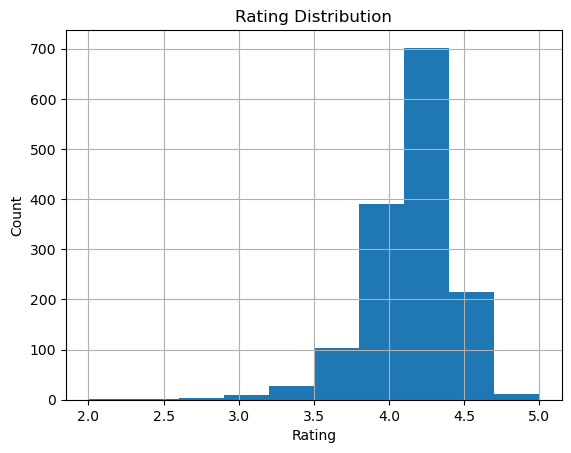

In [31]:
# Rating Distribution Plot
df['rating'].hist(bins=10)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.savefig('D:/Anaconda/Project/Amazone-Sales-Analysis-Dashbaord/Charts/Rating-Distribution-plot')
plt.show()

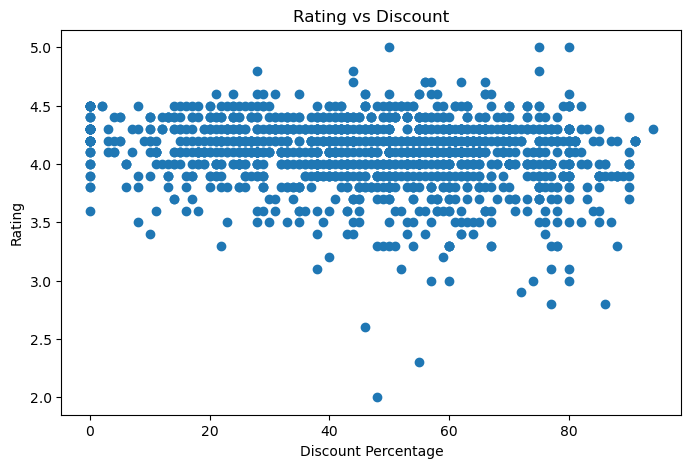

In [32]:
#Rating VS Discount Scatter Plot
plt.figure(figsize=(8,5))

plt.scatter(df['discount_percentage'],df['rating'])

plt.xlabel("Discount Percentage")
plt.ylabel("Rating")
plt.title("Rating vs Discount")
plt.savefig('D:/Anaconda/Project/Amazone-Sales-Analysis-Dashbaord/Charts/Rating-VS-Discount-plot')
plt.show()